Import các thư viện cần thiết như Numpy và Pandas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print(np.__version__)
print(pd.__version__)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000) # set up width 


2.3.5
2.3.3


Đọc datasets

In [2]:
df = pd.read_csv("../data/diabetes.csv")
print(df.shape) # Kích thước có 768 bệnh nhân và 9 cột bệnh lý
print('==================================================')
print(df.info()) #Thông tin kiểu dữ liệu của datasets
print('==================================================')


(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


Kiểm tra giá trị bất thường

In [3]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

zero_values = (df[cols] == 0).sum()

zero_table = pd.DataFrame({
    "Feature": zero_values.index,
    "Zero Values": zero_values.values,
    "Percentage %": (zero_values / len(df) * 100).round(3)
})

print("Các giá trị 0 bất thường")
display(zero_table)

df[cols] = df[cols].replace(0, np.nan)

Các giá trị 0 bất thường


,Feature,Zero Values,Percentage %
Glucose,Glucose,5,0.651
BloodPressure,BloodPressure,35,4.557
SkinThickness,SkinThickness,227,29.557
Insulin,Insulin,374,48.698
BMI,BMI,11,1.432


Thống kê dữ liệu

In [4]:
eda_summary = pd.DataFrame({
    "Feature": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Missing %": (df.isnull().mean() * 100).round(3).values,
    "Mean": df.mean().round(3).values,
    "Std": df.std().round(3).values,
    "Min": df.min().values,
    "Max": df.max().values
})
print("Bảng thống kê dữ liệu")
display(eda_summary.sort_values('Missing %',ascending=False).reset_index(drop=True))

Bảng thống kê dữ liệu


,Feature,Missing Values,Missing %,Mean,Std,Min,Max
0,Insulin,374,48.698,155.548,118.776,14.000,846.00
1,SkinThickness,227,29.557,29.153,10.477,7.000,99.00
2,BloodPressure,35,4.557,72.405,12.382,24.000,122.00
3,BMI,11,1.432,32.457,6.925,18.200,67.10
4,Glucose,5,0.651,121.687,30.536,44.000,199.00
5,Pregnancies,0,0.000,3.845,3.370,0.000,17.00
6,DiabetesPedigreeFunction,0,0.000,0.472,0.331,0.078,2.42
7,Age,0,0.000,33.241,11.760,21.000,81.00
8,Outcome,0,0.000,0.349,0.477,0.000,1.00


Sau khi kiểm tra dữ liệu, phát hiện ra một số cột chứa giá trị 0 không hợp lý. 
Các giá trị này được coi là missing values và được chuyển thành NaN.

Cột Insulin có tỷ lệ thiếu cao nhất (~48,698%), tiếp theo là cột SkinThickness (~29,557%).
Các cột còn lại có tỷ lệ thiếu thấp (<5%).

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [6]:
# Xử lý giá trị trống bằng giá trị trung vị
df.fillna(df.median(), inplace=True)

In [7]:
# kiểm tra giá trị trống sau khi xử lý
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
# KHÔNG CẦN ENCODING vì tất cả dữ liệu trong bảng đã là dạng số.

TRỰC QUAN HÓA DỮ LIỆU

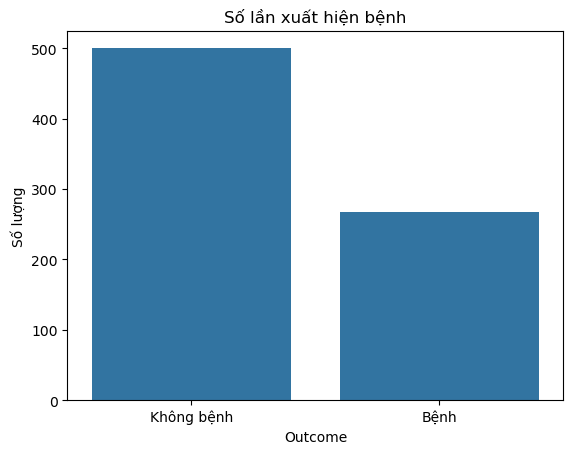

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='Outcome', data=df)
plt.xlabel("Outcome")
plt.ylabel("Số lượng")
plt.title('Số lần xuất hiện bệnh')
plt.xticks([0,1], ["Không bệnh","Bệnh"])
plt.show()

In [10]:
# Số lượng class
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

=> Biểu đồ cho thấy Dữ liệu bị mất cân bằng

CÂN BẰNG DỮ LIỆU (SMOTE)

In [11]:
# Tách X và Y
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [13]:
#  CÂN BẰNG
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=43)
X_resampled, Y_resampled = smote.fit_resample(X, df['Outcome'])

Outcome_count2 = Y_resampled.value_counts()

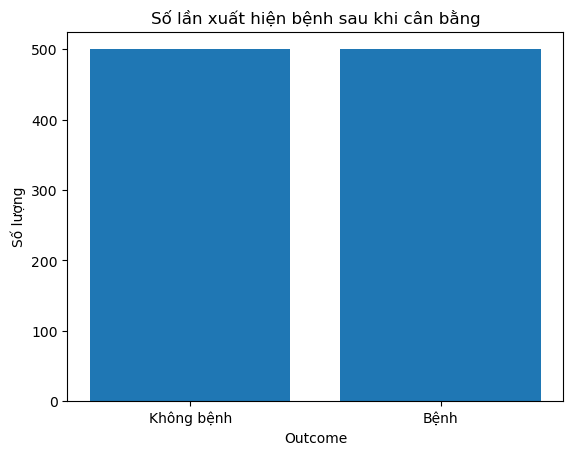

In [14]:
counts = Y_resampled.value_counts()

plt.bar(counts.index, counts.values)

plt.xlabel("Outcome")
plt.ylabel("Số lượng")
plt.title("Số lần xuất hiện bệnh sau khi cân bằng")

plt.xticks([0,1], ["Không bệnh","Bệnh"])

plt.show()

In [15]:
# đếm số lượng của các loại bệnh sau cân bằng
Y_resampled.value_counts()

Outcome
1    500
0    500
Name: count, dtype: int64

TRAIN/TEST

In [16]:
# chia dữ liệu thành train và test 8:2
X_train, X_test, Y_train, Y_test = train_test_split(X_resampled, Y_resampled, test_size=0.2, stratify=Y_resampled,random_state=0)

In [17]:
# (dòng, cột) của tập dữ liệu trước và sau khi chia train test
print(X_resampled.shape, X_train.shape, X_test.shape)

(1000, 8) (800, 8) (200, 8)


SCALING (STANDARDSCALER): giúp đưa dữ liệu về dạng có trung bình (mean) xấp xỉ bằng 0 và độ lệch chuẩn (std) bằng 1 
z = ( x - μ ) / σ

μ : mean
σ : standard deviation

In [18]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_df = pd.DataFrame(X_train, columns = X.columns)
print(X_train_df)

     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  DiabetesPedigreeFunction       Age
0       0.262529 -0.564817       0.642561       0.968868  0.466937  0.107250                 -0.100094 -0.160785
1      -0.607732 -0.683481      -0.870882      -1.813906 -0.993100 -1.152496                  0.708196 -0.872913
2       1.422877 -0.237342       0.550713       0.620211 -0.211901 -0.636436                 -0.716364 -0.427833
3       0.552616  1.147375      -0.959790      -0.104735 -0.211901 -1.339207                 -0.976734  1.441503
4      -1.187906 -0.720382      -0.791956       0.861860 -0.935283  0.051382                  0.040240 -1.050946
..           ...       ...            ...            ...       ...       ...                       ...       ...
795     0.842703  0.532947       3.042324      -0.104735 -0.211901  2.050186                 -0.800732  0.373311
796    -1.187906  0.615110      -0.199745      -0.104735 -0.211901  1.192256                 -0.

FEATURE ENGINEERING

In [19]:
df = pd.read_csv("../data/diabetes.csv")#Reset lại dữ liệu gốc,Tránh lỗi mất cột do chạy notebook nhiều lần
print("=== Original Columns ===")
print(df.columns.tolist())

=== Original Columns ===
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [20]:
# Feature 1: BMI Category
df["BMI_Category"] = pd.cut(df["BMI"],
                           bins=[0, 18.5, 24.9, 29.9, 100],
                           labels=["Underweight", "Normal", "Overweight", "Obese"])

Giải thích tại sao lại tạo Feature BMI Category
1.BMI là biến liên tục, nhưng trong thực tế y khoa, BMI thường được phân loại thành các nhóm như:
    Gầy (Underweight)
    Bình thường (Normal)
    Thừa cân (Overweight)
    Béo phì (Obese)
2.Việc chuyển BMI thành dạng phân loại giúp mô hình:
    Dễ nhận diện các mức độ rủi ro sức khỏe
    Nắm bắt được các ngưỡng quan trọng (threshold) thay vì chỉ giá trị số
3.Ý nghĩa
    Các nghiên cứu cho thấy người thừa cân và béo phì có nguy cơ mắc bệnh tiểu đường cao hơn, do đó feature này giúp mô hình học tốt hơn về nguy cơ bệnh.

In [21]:
# Feature 2: Glucose/BMI Ratio
df["Glucose_BMI_Ratio"] = df["Glucose"] / (df["BMI"] + 1e-5)

Giải thích tại sao lại tạo Feature Glucose/BMI Ratio
1.Glucose và BMI là hai yếu tố quan trọng ảnh hưởng đến bệnh tiểu đường. Tuy nhiên, khi xét riêng lẻ, mỗi biến chỉ phản ánh một khía cạnh.
2.Việc tạo tỷ lệ giữa Glucose và BMI giúp:
    Kết hợp thông tin của hai biến thành một đặc trưng mới
    Phản ánh mối quan hệ tương đối giữa đường huyết và thể trạng
3.Ý nghĩa
    Một người có glucose cao nhưng BMI thấp có thể có nguy cơ khác so với người có cùng glucose nhưng BMI cao. Feature này giúp mô hình phân biệt các trường hợp đó tốt hơn.

In [22]:
# Feature 3: Age Group
df["Age_Group"] = pd.cut(df["Age"],
                        bins=[0, 30, 50, 100],
                        labels=["Young", "Middle", "Old"])

Giải thích tại sao lại tạo Feature Age Group
1.Tuổi là biến liên tục, nhưng nguy cơ mắc bệnh thường tăng theo từng giai đoạn tuổi chứ không tăng đều.
2.Việc chia nhóm tuổi giúp:
    Đơn giản hóa dữ liệu
    Làm nổi bật các nhóm có nguy cơ khác nhau
3.Ý nghĩa 
    Người lớn tuổi thường có nguy cơ mắc tiểu đường cao hơn so với người trẻ. Feature này giúp mô hình học được xu hướng theo nhóm tuổi rõ ràng hơn.

PREVIEW FEATURES

In [23]:
print("\n=== Preview Features ===")
print(df[["BMI_Category", "Glucose_BMI_Ratio", "Age_Group"]].head(10))

print("\n=== BMI_Category Distribution ===")
print(df["BMI_Category"].value_counts())

print("\n=== Age_Group Distribution ===")
print(df["Age_Group"].value_counts())

print("\n=== Glucose_BMI_Ratio Stats ===")
print(df["Glucose_BMI_Ratio"].describe())


=== Preview Features ===
  BMI_Category  Glucose_BMI_Ratio Age_Group
0        Obese       4.404761e+00    Middle
1   Overweight       3.195488e+00    Middle
2       Normal       7.854074e+00    Middle
3   Overweight       3.167259e+00     Young
4        Obese       3.178654e+00    Middle
5   Overweight       4.531248e+00     Young
6        Obese       2.516128e+00     Young
7        Obese       3.257789e+00     Young
8        Obese       6.459014e+00       Old
9          NaN       1.250000e+07       Old

=== BMI_Category Distribution ===
BMI_Category
Obese          472
Overweight     179
Normal         102
Underweight      4
Name: count, dtype: int64

=== Age_Group Distribution ===
Age_Group
Young     417
Middle    270
Old        81
Name: count, dtype: int64

=== Glucose_BMI_Ratio Stats ===
count    7.680000e+02
mean     1.493528e+05
std      1.259901e+06
min      0.000000e+00
25%      3.053626e+00
50%      3.768472e+00
75%      4.623584e+00
max      1.360000e+07
Name: Glucose_BMI_Rat

Visualization

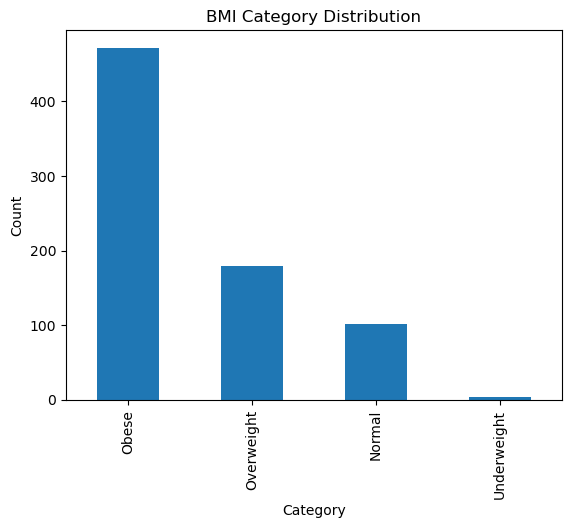

In [24]:
df["BMI_Category"].value_counts().plot(kind="bar")
plt.title("BMI Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

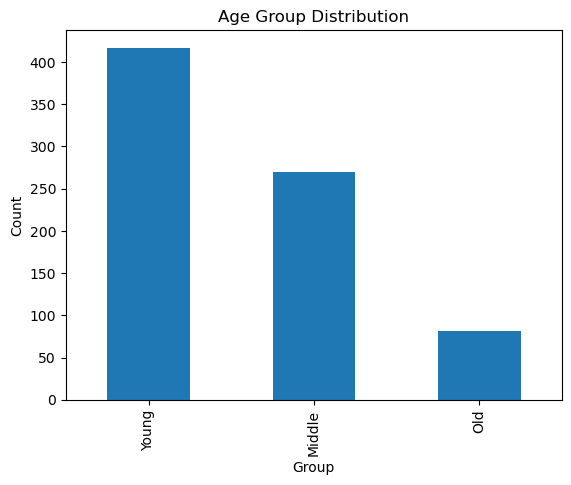

In [25]:
df["Age_Group"].value_counts().plot(kind="bar")
plt.title("Age Group Distribution")
plt.xlabel("Group")
plt.ylabel("Count")
plt.show()

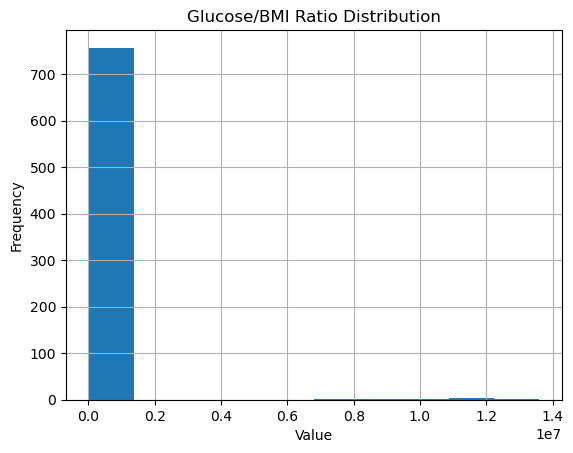

In [26]:
df["Glucose_BMI_Ratio"].hist()
plt.title("Glucose/BMI Ratio Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

Encoding

In [28]:
df = pd.get_dummies(df, columns=["BMI_Category", "Age_Group"], drop_first=True)

print("\n=== Columns AFTER Encoding ===")
print(df.columns.tolist())


=== Columns AFTER Encoding ===
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'Glucose_BMI_Ratio', 'BMI_Category_Normal', 'BMI_Category_Overweight', 'BMI_Category_Obese', 'Age_Group_Middle', 'Age_Group_Old']


ĐÁNH GIÁ FEATURE (Tỷ lệ dự đoán đúng của mô hình )

In [29]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# BEFORE (không dùng feature mới)
X_old = df.drop(["Outcome", "Glucose_BMI_Ratio"], axis=1)
y = df["Outcome"]

model = RandomForestClassifier(random_state=42)
score_old = cross_val_score(model, X_old, y, cv=5).mean()

# AFTER (có feature mới)
X_new = df.drop("Outcome", axis=1)
score_new = cross_val_score(model, X_new, y, cv=5).mean()

print("\n=== MODEL EVALUATION ===")
print("Accuracy BEFORE:", score_old)
print("Accuracy AFTER:", score_new)


=== MODEL EVALUATION ===
Accuracy BEFORE: 0.7708938120702827
Accuracy AFTER: 0.7721755368814193


FEATURE IMPORTANCE


=== TOP 10 IMPORTANT FEATURES ===
Glucose                     0.199453
BMI                         0.123321
Glucose_BMI_Ratio           0.120096
Age                         0.101883
DiabetesPedigreeFunction    0.100293
BloodPressure               0.077529
Pregnancies                 0.072451
Insulin                     0.061364
SkinThickness               0.056240
BMI_Category_Obese          0.038510
dtype: float64


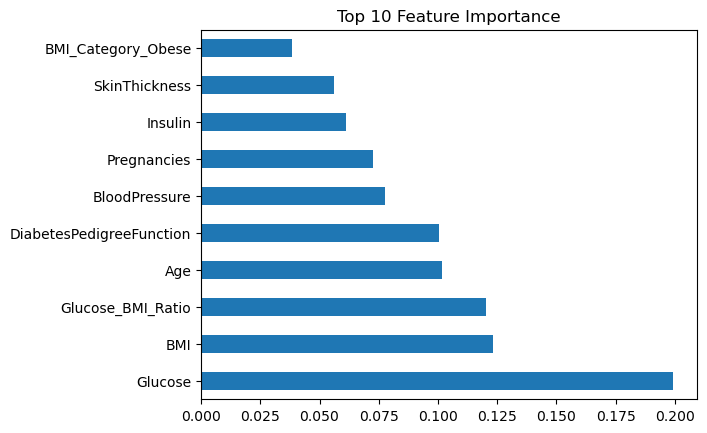

In [30]:
model.fit(X_new, y)

importances = pd.Series(model.feature_importances_, index=X_new.columns)
top_features = importances.sort_values(ascending=False).head(10)

print("\n=== TOP 10 IMPORTANT FEATURES ===")
print(top_features)

top_features.plot(kind="barh")
plt.title("Top 10 Feature Importance")
plt.show()